## Connect to Database and pull data

In [2]:
!pip install pymysql
!pip install boto3
!pip install sqlalchemy
!pip install python-dotenv
!pip install prophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 16.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 991.0/991.0 kB 18.9 MB/s eta 0:00:00a 0:00:01


In [ ]:
# package for env variables in google colab: https://pypi.org/project/colab-env/
!pip install colab-env -qU
import colab_env

  Preparing metadata (setup.py) ... done
Mounted at /content/gdrive


In [ ]:
from colab_env import envvar_handler # modify env variables in var.env file in google drive

In [6]:
import pymysql
import sys
import boto3
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [8]:
connection = pymysql.connect(
    host="database-dm4ds.c384k0y2av79.us-west-1.rds.amazonaws.com",
    user="ROuser",
    port=3306,
    passwd="adsd3d3dfxds!@@QAS",
    database="myDB"
)

In [ ]:
connection.close()

In [9]:
with connection.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

CSU_Data_2010
CSU_Data_2011
CSU_Data_2012
CSU_Data_2013
CSU_Data_2014
CSU_Data_2015
CSU_Data_2016
CSU_Data_2017
CSU_salaries_data
Inflation_data
SuperBowl_coinTosses
UCOP_Data_2010
UCOP_Data_2011
UCOP_Data_2012
UCOP_Data_2013
UCOP_Data_2014
UCOP_Data_2015
UCOP_Data_2016
UCOP_Data_2017
UCOP_Data_2018
UCOP_Data_2019
UCOP_Data_2020
UCOP_Data_2021
UCOP_Data_2022
UCOP_Data_2023
google_elev_68sites
iris_data
nhl_goalieDate
nhl_playerDate
nhl_teamDate


In [12]:
years = range(2010, 2024)
dfs = []

for year in years:
    query = f"""
    SELECT '{year}' AS year, location, title, `regular.pay`
    FROM `UCOP_Data_{year}`
    """
    df = pd.read_sql(query, con=connection)
    if year in range(2013,2016):
        df.loc[:,"location":]=df.loc[:,"location":].applymap(lambda x:x.strip("'"))
        for i in ['year','regular.pay']:
            df[i] = pd.to_numeric(df[i])
    dfs.append(df)

full_data = pd.concat(dfs, ignore_index=True)
full_data.head()


/Users/claytonchan/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/Users/claytonchan/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/Users/claytonchan/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/Users/claytonchan/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
1,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,5369.42
2,2010,Berkeley,TEACHING ASSISTANT - GSHIP,4802.00
3,2010,Berkeley,GRAD STDNT RES- NO REMISSION,3409.01
4,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,11673.90


**EDA**

In [13]:
full_data = full_data.dropna()

In [14]:
full_data["location"].unique()

array(['Santa Cruz', 'Berkeley', 'DANR', 'Davis', 'Irvine', 'Los Angeles',
       'Merced', 'Riverside', 'San Diego', 'San Francisco',
       'Santa Barbara', 'UCOP', 'ASUCLA', 'Hastings College Of Law',
       'Hastings'], dtype=object)

In [15]:
to_drop = ["San Francisco", "UCOP", "DANR", "Hastings", "Hastings College Of Law", "ASUCLA"]
full_data = full_data[~full_data["location"].isin(to_drop)]

In [16]:
pattern = r"""(?ix)                     # (?i)=ignore-case  (?x)=verbose mode
    \b(?:                               # word-start, then one of…
        prof(?:essors?\b|\.?\b)         #  "professor" / "professors" / "prof" / "prof."
      | lect(?:urer?s?\b|\b)            #  "lecturer(s)" / "lect"
    )
"""

filtered = full_data[full_data['title'].str.contains(pattern, regex=True, na=False)]


In [17]:
filtered = filtered[~(filtered["title"].str.contains("SUMMER"))]

In [18]:
def title_assign(x):
    if "PROFL" in x or "PROFESSIONAL" in x:
        return "OTHER"
    elif "VST" in x and "ASST" in x:
        return "VST ASST"
    elif "VST" in x and "ASSOC" in x:
        return "VST ASSOC"
    elif "VST" in x:
        return "VST PROF"
    elif "ADJ" in x and "ASST" in x:
        return "ADJ ASST"
    elif ("ASOC" in x or "ASSOC" in x) and "ADJ" in x:
        return "ADJ ASOC"
    elif "ADJ" in x:
        return "ADJ PROF"
    elif ("ASST" in x or "ASSIST" in x) and "PROF" in x:
        return "ASST PROF"
    elif "ASSOC" in x and "PROF" in x:
        return "ASSOC PROF"
    elif "PROF" in x:
        return "PROF"
    elif "SR" in x and "LECT" in x:
        return "SR LECT"
    elif "LECT" in x:
        return "LECT"
    else:
        return "OTHER"

In [19]:
filtered['prof_rank'] = (
    filtered['title']
        .str.upper()
        .fillna('')
        .apply(title_assign)
)
filtered = filtered[filtered['regular.pay']>0]
filtered.head()


,year,location,title,regular.pay,prof_rank
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT


In [20]:
avg_salary = (
    filtered
      .groupby(['prof_rank', 'location'], as_index=False)
      .agg(avg_regular_pay=('regular.pay', 'mean'))
)

avg_salary


,prof_rank,location,avg_regular_pay
0,ADJ ASOC,Berkeley,76209.988050
1,ADJ ASOC,Davis,78069.147082
2,ADJ ASOC,Irvine,75783.453233
3,ADJ ASOC,Los Angeles,81951.866162
4,ADJ ASOC,Riverside,83422.896552
...,...,...,...
90,VST PROF,Los Angeles,26274.428080
91,VST PROF,Riverside,14328.400000
92,VST PROF,San Diego,26011.854286
93,VST PROF,Santa Barbara,24105.281000


In [21]:
avg_by_campus

NameError: name 'avg_by_campus' is not defined

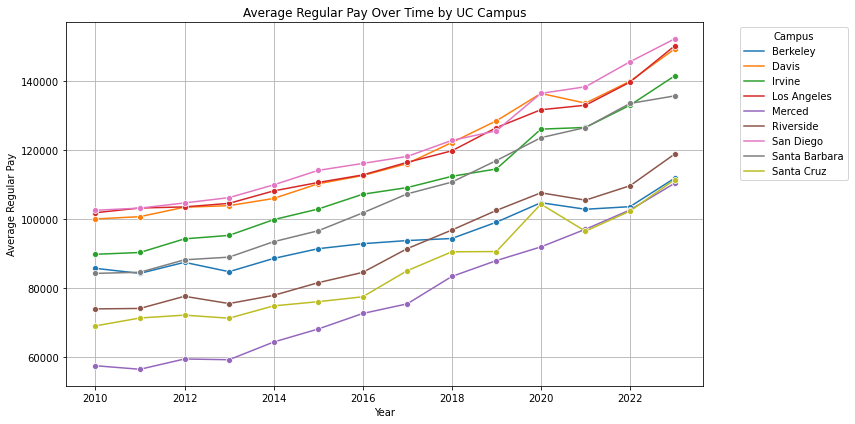

<Figure size 432x288 with 0 Axes>

In [24]:
#time trend analysis plot by campus
avg_by_campus = filtered.groupby(['year', 'location'])['regular.pay'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_by_campus, x='year', y='regular.pay', hue='location', marker="o")

plt.title("Average Regular Pay Over Time by UC Campus")
plt.ylabel("Average Regular Pay")
plt.xlabel("Year")
plt.legend(title='Campus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()
plt.savefig("Campus.png")

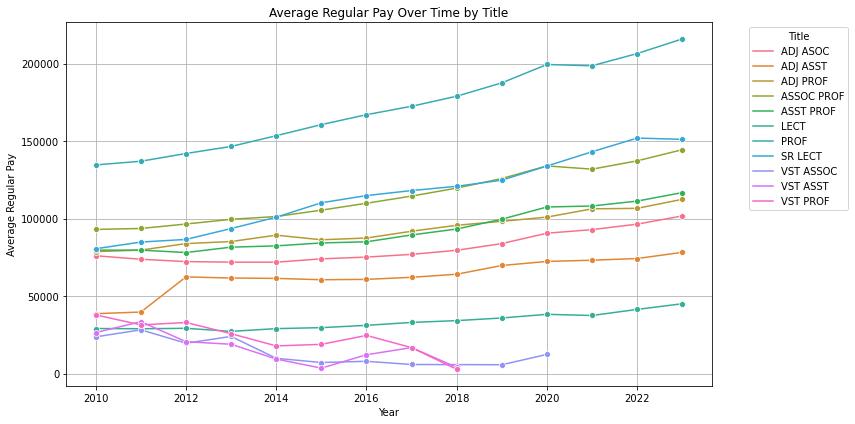

<Figure size 432x288 with 0 Axes>

In [25]:
#time trend analysis plot by campus
avg_by_campus = filtered.groupby(['year', 'prof_rank'])['regular.pay'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_by_campus, x='year', y='regular.pay', hue='prof_rank', marker="o")

plt.title("Average Regular Pay Over Time by Title")
plt.ylabel("Average Regular Pay")
plt.xlabel("Year")
plt.legend(title='Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()
plt.savefig("Title.png")

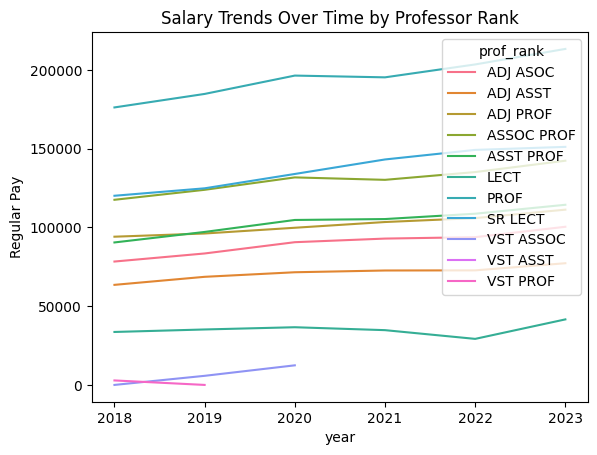

In [ ]:
# By Rank
avg_rank = filtered.groupby(['year', 'prof_rank'])['regular.pay'].mean().reset_index()
sns.lineplot(data=avg_rank, x='year', y='regular.pay', hue='prof_rank')
plt.title("Salary Trends Over Time by Professor Rank")
plt.ylabel("Regular Pay")
plt.show()

In [ ]:
#want to see if there are disparities
summary = filtered.groupby(['year', 'prof_rank'])['regular.pay'].agg(['count', 'mean', 'median']).reset_index()
summary.head()


,year,prof_rank,count,mean,median
0,2018,ADJ ASOC,190,78354.642105,93829.0
1,2018,ADJ ASST,421,63548.446556,67167.0
2,2018,ADJ PROF,298,94131.117450,88176.5
3,2018,ASSOC PROF,3041,117566.101282,115966.0
4,2018,ASST PROF,3898,90478.310672,95426.0


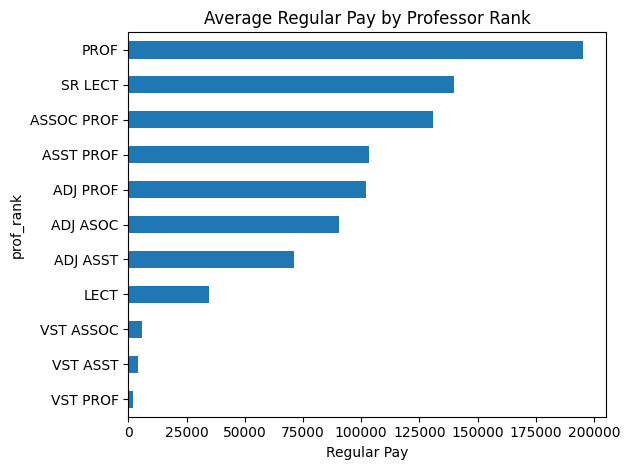

In [ ]:
#looking by position
filtered.groupby('prof_rank')['regular.pay'].mean().sort_values().plot(kind='barh')
plt.title("Average Regular Pay by Professor Rank")
plt.xlabel("Regular Pay")
plt.tight_layout()
plt.show()


In [ ]:
#random forest
X = filtered[['year', 'location', 'prof_rank']]
y = filtered['regular.pay']

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['location', 'prof_rank'])
], remainder='passthrough')

# Model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
print("R² score:", pipeline.score(X_test, y_test))

R² score: 0.5683763136647576


In [ ]:
#checking feature importance
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
15,cat__prof_rank_PROF,0.695058
14,cat__prof_rank_LECT,0.226080
20,remainder__year,0.020130
3,cat__location_Los Angeles,0.017904
12,cat__prof_rank_ASSOC PROF,0.017275
5,cat__location_Riverside,0.004923
10,cat__prof_rank_ADJ ASST,0.004233
16,cat__prof_rank_SR LECT,0.003491
0,cat__location_Berkeley,0.001998
8,cat__location_Santa Cruz,0.001848


In [ ]:
#mse and mae for randomforest model
y_pred = pipeline.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


MAE: 40032.89258114064
RMSE: 56973.15221971202


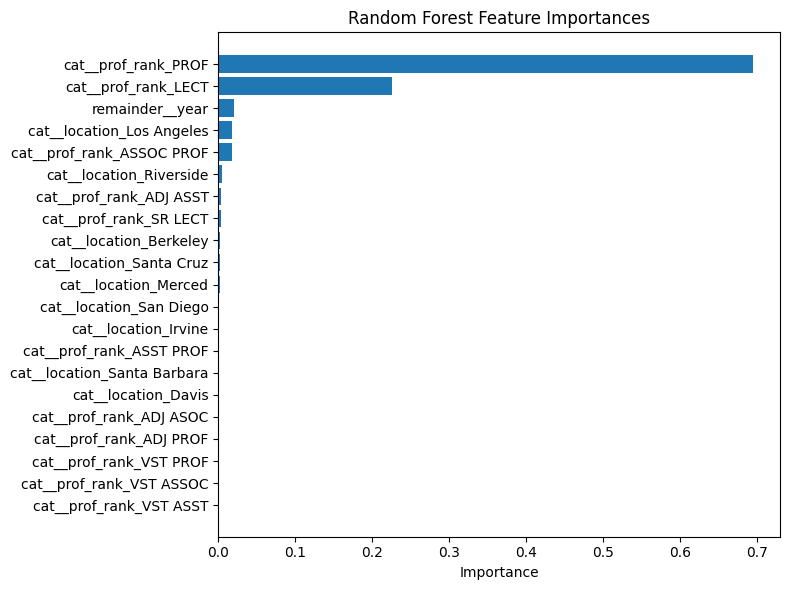

In [ ]:
#feature importance plot
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values(by='importance', ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

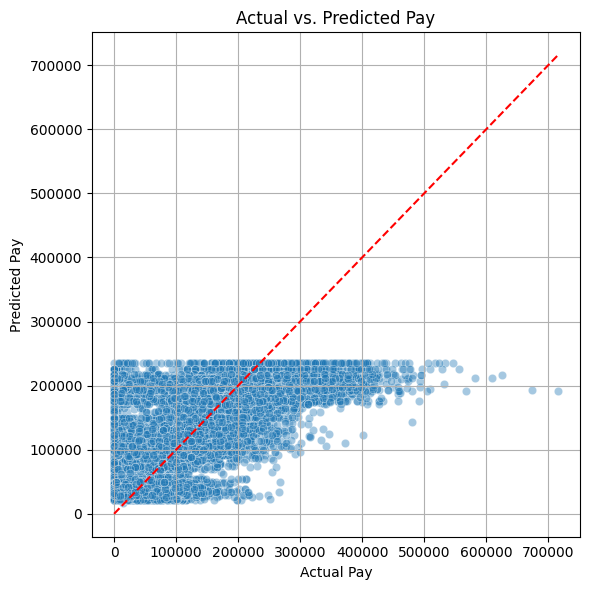

In [ ]:
#prediction plot
y_pred = pipeline.predict(X_test)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual Pay")
plt.ylabel("Predicted Pay")
plt.title("Actual vs. Predicted Pay")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#time series prophet

# Group to get annual UC-wide average pay
df_avg = filtered.groupby('year')['regular.pay'].mean().reset_index()
df_avg['ds'] = pd.to_datetime(df_avg['year'], format='%Y')  # Prophet needs datetime
df_avg = df_avg.rename(columns={'regular.pay': 'y'})[['ds', 'y']]

model = Prophet()
model.fit(df_avg)

# Forecast 5 years into the future
future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/7omnd9he.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/s3nvqymy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87789', 'data', 'file=/tmp/tmp5qjph26_/7omnd9he.json', 'init=/tmp/tmp5qjph26_/s3nvqymy.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_modeldrhhc6bn/prophet_model-20250606230155.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:01:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:01:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

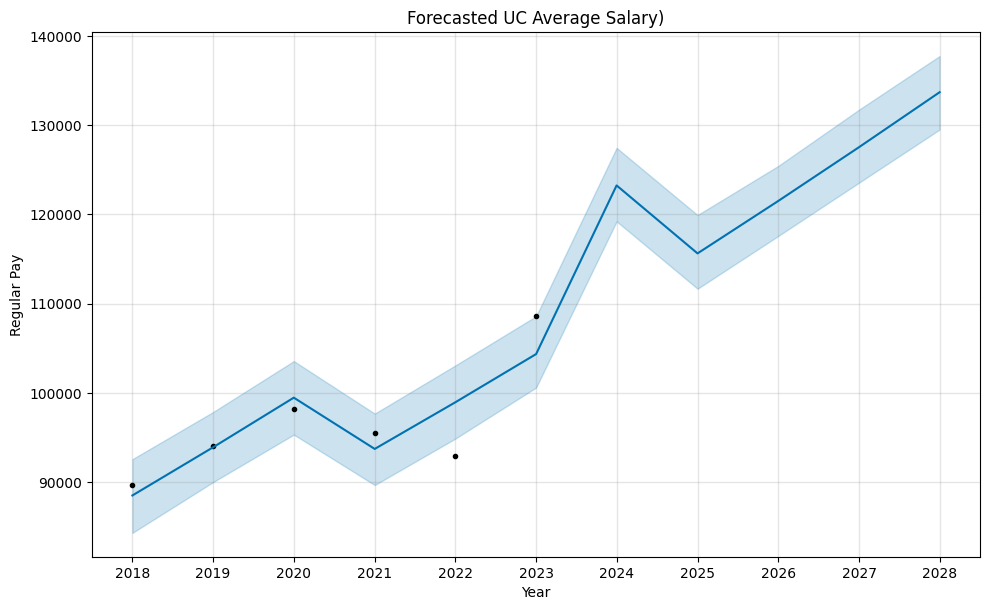

In [ ]:
model.plot(forecast)
plt.title("Forecasted UC Average Salary)")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.grid(True)
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/1iatn23j.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/ixmd1_5e.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=81614', 'data', 'file=/tmp/tmp5qjph26_/1iatn23j.json', 'init=/tmp/tmp5qjph26_/ixmd1_5e.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_model97n41f2a/prophet_model-20250606234453.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

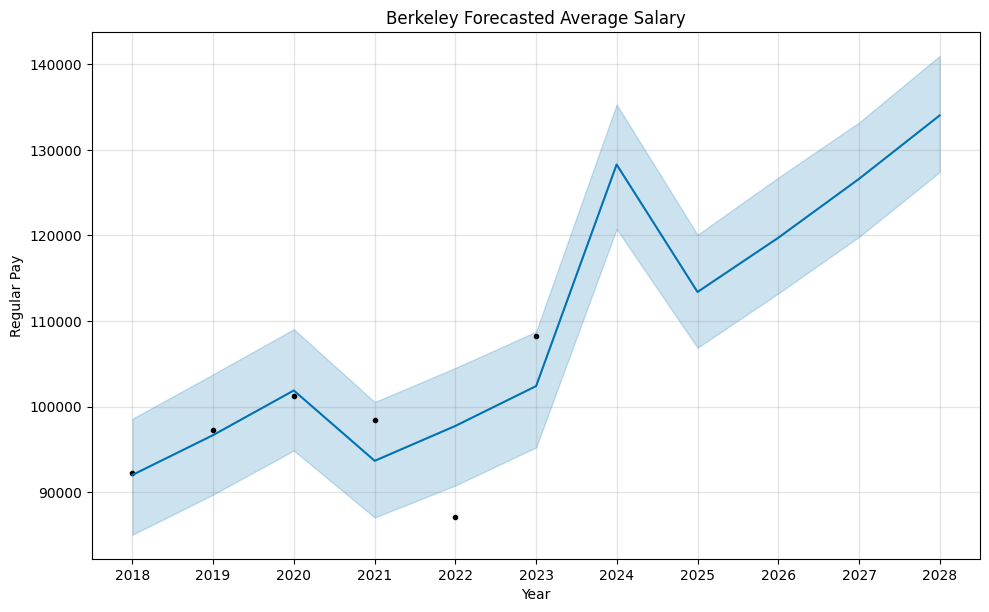

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/9420tkr8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/0x02z84u.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28169', 'data', 'file=/tmp/tmp5qjph26_/9420tkr8.json', 'init=/tmp/tmp5qjph26_/0x02z84u.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_modelt2h5wza5/prophet_model-20250606234454.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

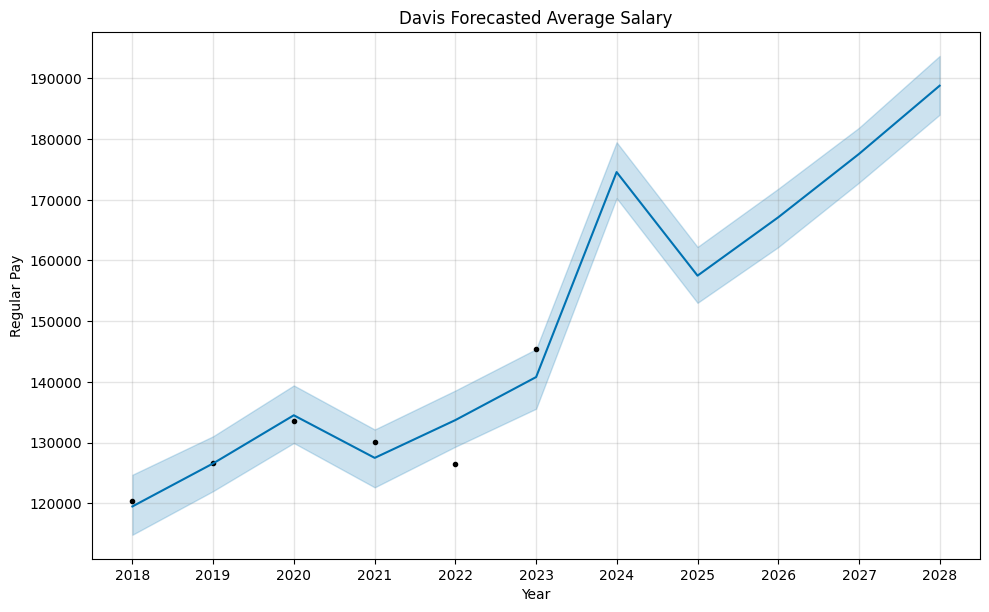

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/sk8rzn3a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/jkd87qd6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11601', 'data', 'file=/tmp/tmp5qjph26_/sk8rzn3a.json', 'init=/tmp/tmp5qjph26_/jkd87qd6.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_modelq1rt_wia/prophet_model-20250606234455.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

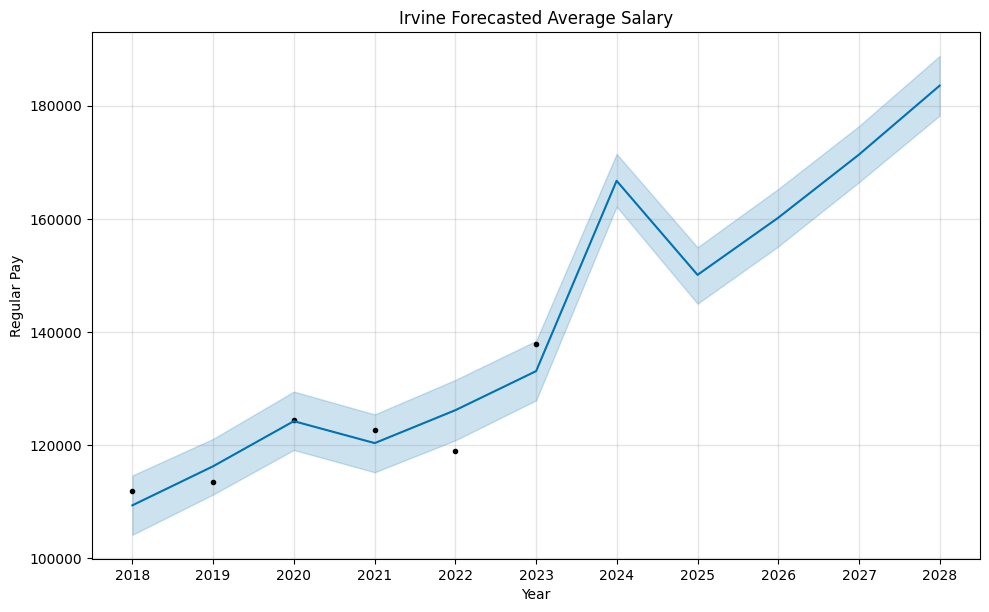

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/4hls366m.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/mt3kxzf_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94446', 'data', 'file=/tmp/tmp5qjph26_/4hls366m.json', 'init=/tmp/tmp5qjph26_/mt3kxzf_.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_model3kzsrycg/prophet_model-20250606234456.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

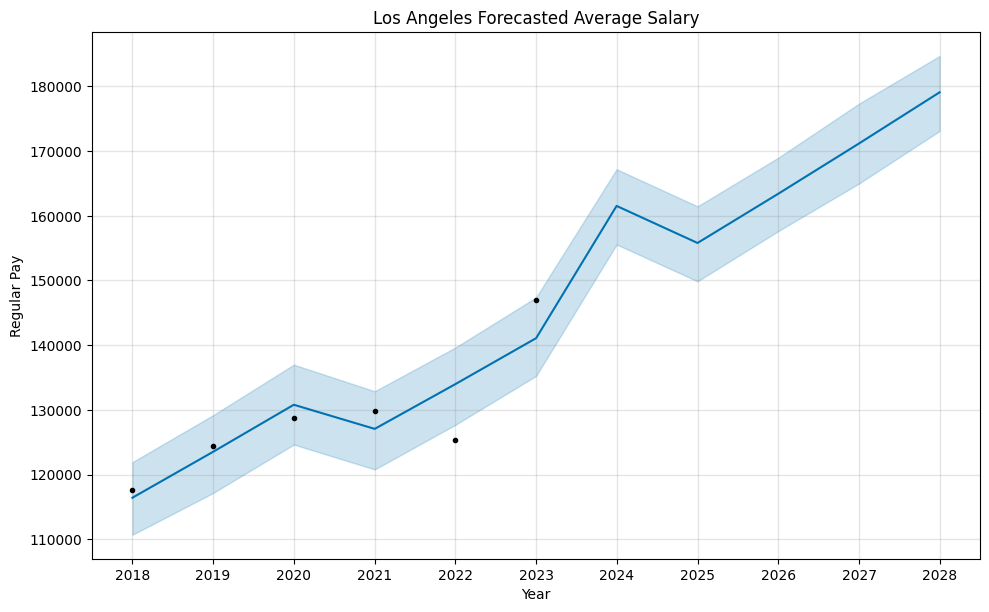

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/qe0vehwx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/1uo84f10.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67726', 'data', 'file=/tmp/tmp5qjph26_/qe0vehwx.json', 'init=/tmp/tmp5qjph26_/1uo84f10.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_modelwvdikzz5/prophet_model-20250606234456.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

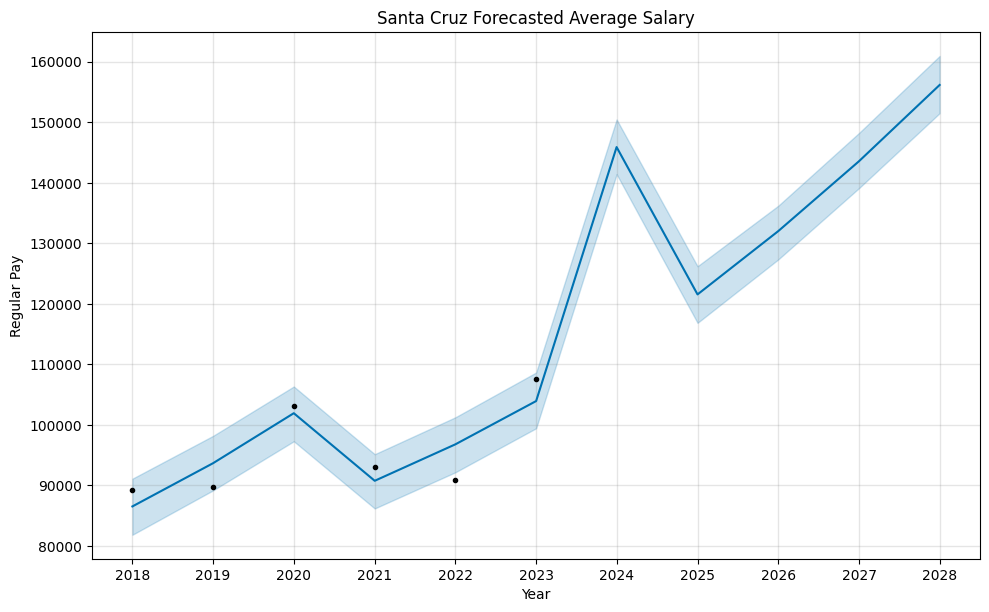

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/mkl_lvlg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/osu3qq7l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13821', 'data', 'file=/tmp/tmp5qjph26_/mkl_lvlg.json', 'init=/tmp/tmp5qjph26_/osu3qq7l.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_model0lc4c3a3/prophet_model-20250606234457.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

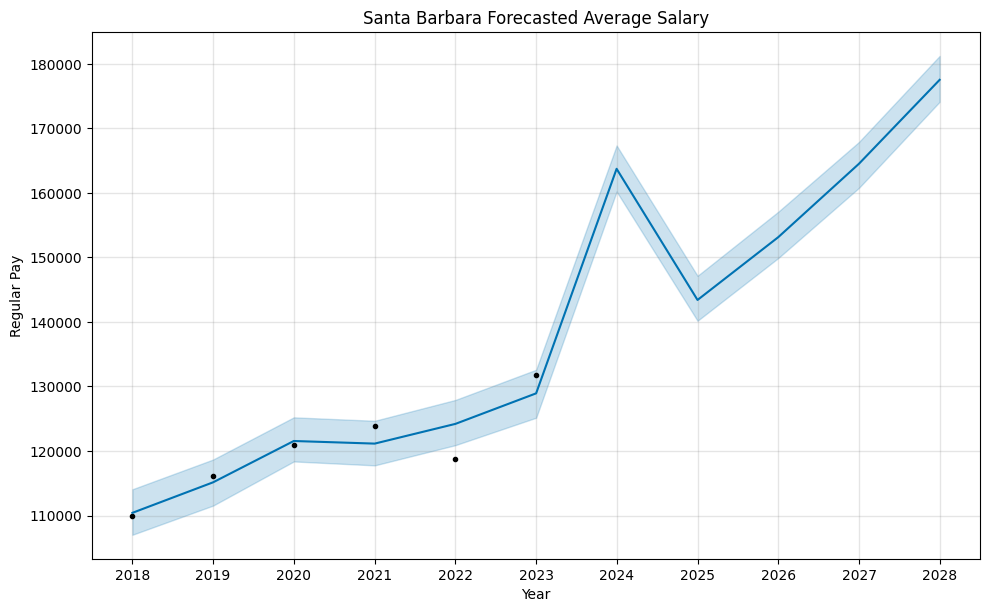

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/s_cvri41.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/j606neuw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48681', 'data', 'file=/tmp/tmp5qjph26_/s_cvri41.json', 'init=/tmp/tmp5qjph26_/j606neuw.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_modelwumt98fa/prophet_model-20250606234457.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

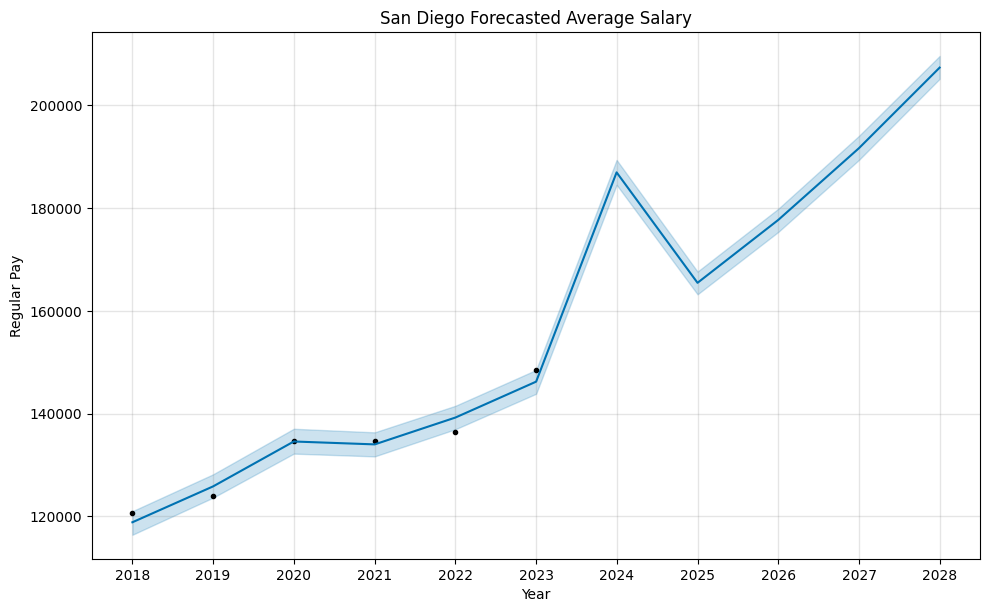

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/1hcbleq_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/dgowappn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17045', 'data', 'file=/tmp/tmp5qjph26_/1hcbleq_.json', 'init=/tmp/tmp5qjph26_/dgowappn.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_model9dw8ppkc/prophet_model-20250606234458.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

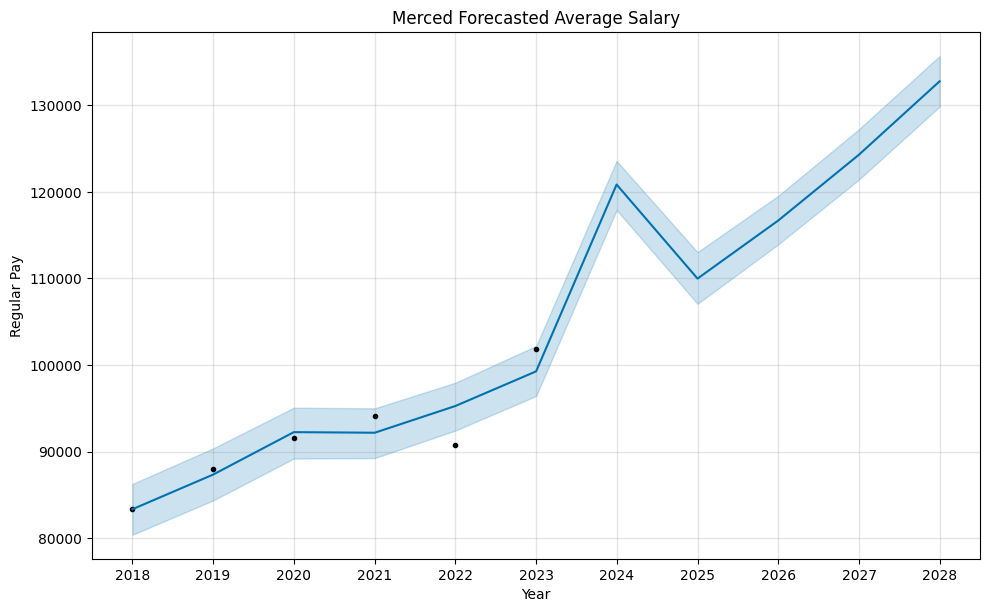

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/wl5x8q3p.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5qjph26_/xhlacphq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33794', 'data', 'file=/tmp/tmp5qjph26_/wl5x8q3p.json', 'init=/tmp/tmp5qjph26_/xhlacphq.json', 'output', 'file=/tmp/tmp5qjph26_/prophet_modelfug890ii/prophet_model-20250606234458.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:44:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:44:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

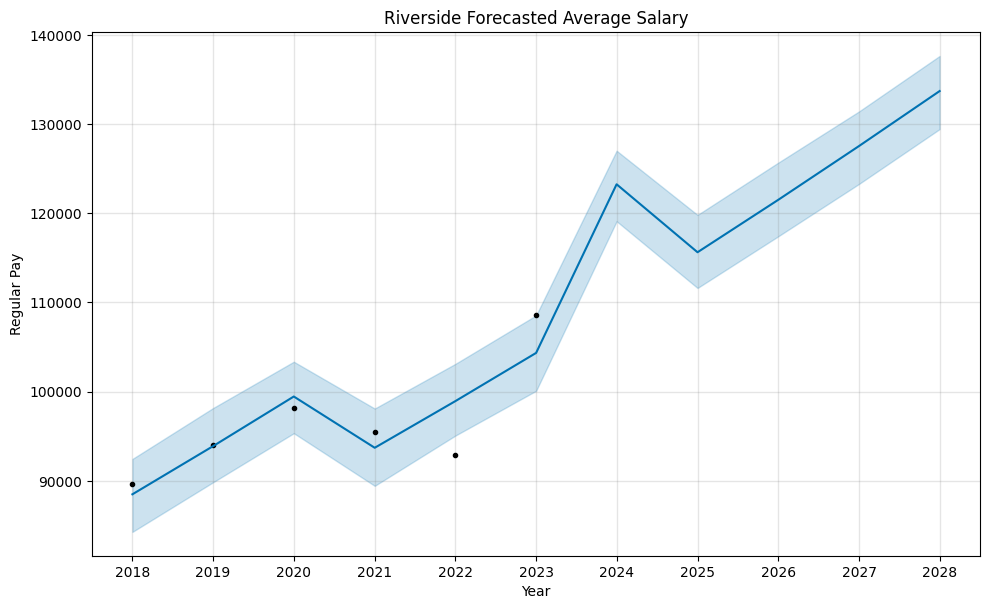

In [ ]:
#campus specific
for campus in filtered['location'].unique():
    df_campus = filtered[filtered['location'] == campus]
    df_avg = df_campus.groupby('year')['regular.pay'].mean().reset_index()
    df_avg['ds'] = pd.to_datetime(df_avg['year'], format='%Y')
    df_avg = df_avg.rename(columns={'regular.pay': 'y'})[['ds', 'y']]

    if len(df_avg) < 5:
        continue  # skip if not enough data

    model = Prophet()
    model.fit(df_avg)

    future = model.make_future_dataframe(periods=5, freq='Y')
    forecast = model.predict(future)

    model.plot(forecast)
    plt.title(f"{campus} Forecasted Average Salary")
    plt.ylabel("Regular Pay")
    plt.xlabel("Year")
    plt.show()
